<a href="https://colab.research.google.com/github/jeonghoon-jang/TIL/blob/main/1d%20CNN-IMDB%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import torch
import urllib.request
from tqdm import tqdm
from collections import Counter
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

In [4]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
!pip install datasets

from datasets import load_dataset
import pandas as pd

# IMDB 데이터 로드
dataset = load_dataset("stanfordnlp/imdb")

# train + test 합쳐서 데이터프레임으로
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])
df = pd.concat([train_df, test_df], ignore_index=True)

# 교재랑 컬럼명 맞추기 (교재는 review, sentiment)
df = df.rename(columns={'text': 'review', 'label': 'sentiment'})
# label이 0/1로 되어있으면 교재 형식(positive/negative)으로
df['sentiment'] = df['sentiment'].map({0: 'negative', 1: 'positive'})

df

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,review,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",negative
2,If only to avoid making this type of film in t...,negative
3,This film was probably inspired by Godard's Ma...,negative
4,"Oh, brother...after hearing about this ridicul...",negative
...,...,...
49995,Just got around to seeing Monster Man yesterda...,positive
49996,I got this as part of a competition prize. I w...,positive
49997,I got Monster Man in a box set of three films ...,positive
49998,"Five minutes in, i started to feel how naff th...",positive


In [6]:
print('결측값 여부 :',df.isnull().values.any())


결측값 여부 : False


<Axes: xlabel='sentiment'>

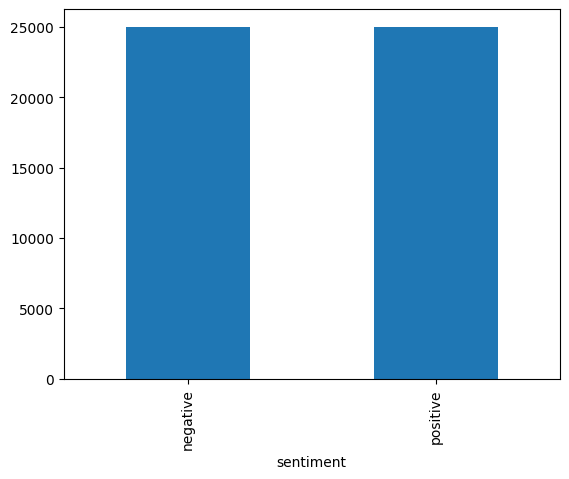

In [7]:
df['sentiment'].value_counts().plot(kind='bar')

In [8]:
df['sentiment'] = df['sentiment'].replace(['positive','negative'],[1, 0])
df.head()


/tmp/ipykernel_9189/1486921325.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace(['positive','negative'],[1, 0])


,review,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


<Axes: xlabel='sentiment'>

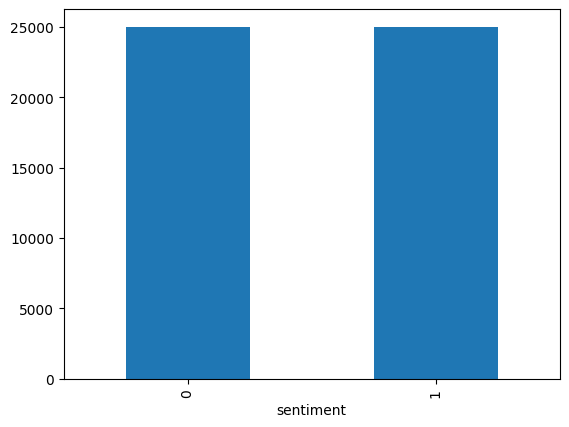

In [9]:
df['sentiment'].value_counts().plot(kind='bar')

In [10]:
X_data = df['review']
y_data = df['sentiment']
print('영화 리뷰의 개수: {}'.format(len(X_data)))
print('레이블의 개수: {}'.format(len(y_data)))

영화 리뷰의 개수: 50000
레이블의 개수: 50000


In [11]:

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.5, random_state=0, stratify=y_data) #훈련데이터와 테스트데이터 5:5로 나누기
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=.2, random_state=0, stratify=y_train) #훈련데이터를 다시 8:2로 훈련/검증으로 나누기

print('--------훈련 데이터의 비율-----------')
print(f'부정 리뷰 = {round(y_train.value_counts()[0]/len(y_train) * 100,3)}%')
print(f'긍정 리뷰 = {round(y_train.value_counts()[1]/len(y_train) * 100,3)}%')
print('--------검증 데이터의 비율-----------')
print(f'부정 리뷰 = {round(y_valid.value_counts()[0]/len(y_valid) * 100,3)}%')
print(f'긍정 리뷰 = {round(y_valid.value_counts()[1]/len(y_valid) * 100,3)}%')
print('--------테스트 데이터의 비율-----------')
print(f'부정 리뷰 = {round(y_test.value_counts()[0]/len(y_test) * 100,3)}%')
print(f'긍정 리뷰 = {round(y_test.value_counts()[1]/len(y_test) * 100,3)}%')


--------훈련 데이터의 비율-----------
부정 리뷰 = 50.0%
긍정 리뷰 = 50.0%
--------검증 데이터의 비율-----------
부정 리뷰 = 50.0%
긍정 리뷰 = 50.0%
--------테스트 데이터의 비율-----------
부정 리뷰 = 50.0%
긍정 리뷰 = 50.0%


In [12]:
#토큰화, TVT data 모두 토큰화 진행하고 대문자->소문자 변환도 같이 진행
def tokenize(sentences):
  tokenized_sentences = []
  for sent in tqdm(sentences):
    tokenized_sent = word_tokenize(sent)
    tokenized_sent = [word.lower() for word in tokenized_sent]
    tokenized_sentences.append(tokenized_sent)
  return tokenized_sentences

tokenized_X_train = tokenize(X_train)
tokenized_X_valid = tokenize(X_valid)
tokenized_X_test = tokenize(X_test)



100%|██████████| 25000/25000 [00:21<00:00, 1176.18it/s]


In [13]:
# 상위 샘플 2개 출력
for sent in tokenized_X_train[:2]:
  print(sent)

['murder', 'in', 'mesopotamia', ',', 'i', 'have', 'always', 'considered', 'one', 'of', 'the', 'better', 'poirot', 'books', ',', 'as', 'it', 'is', 'very', 'creepy', 'and', 'has', 'an', 'ingenious', 'ending', '.', 'there', 'is', 'no', 'doubt', 'that', 'the', 'tv', 'adaptation', 'is', 'visually', 'striking', ',', 'with', 'some', 'lovely', 'photography', 'and', 'a', 'very', 'haunting', 'music', 'score', '.', 'as', 'always', 'david', 'suchet', 'is', 'impeccable', 'as', 'hercule', 'poirot', ',', 'the', 'comedic', 'highlight', 'of', 'the', 'episode', 'being', 'poirot', "'s", 'battle', 'with', 'a', 'mosquito', 'in', 'the', 'middle', 'of', 'the', 'night', ',', 'and', 'hugh', 'fraser', 'is', 'good', 'as', 'the', 'rather', 'naive', 'captain', 'hastings', '.', 'the', 'remainder', 'of', 'the', 'cast', 'turn', 'in', 'decent', 'performances', ',', 'but', 'are', 'careful', 'not', 'to', 'overshadow', 'the', 'two', 'leads', ',', 'a', 'danger', 'in', 'some', 'christie', 'adaptations', '.', 'some', 'of', 

In [14]:
# Vocab 만들기
word_list = []
for sent in tokenized_X_train:
    for word in sent:
      word_list.append(word)

word_counts = Counter(word_list)
print('총 단어수 :', len(word_counts))


총 단어수 : 100365


In [15]:

print('훈련 데이터에서의 단어 the의 등장 횟수 :', word_counts['the'])
print('훈련 데이터에서의 단어 love의 등장 횟수 :', word_counts['love'])


훈련 데이터에서의 단어 the의 등장 횟수 : 265078
훈련 데이터에서의 단어 love의 등장 횟수 : 5101


In [16]:

vocab = sorted(word_counts, key=word_counts.get, reverse=True)
print('등장 빈도수 상위 10개 단어')
print(vocab[:10])


등장 빈도수 상위 10개 단어
['the', ',', '.', 'a', 'and', 'of', 'to', 'is', '/', '>']


In [17]:
threshold = 3
total_cnt = len(word_counts) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :',total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


단어 집합(vocabulary)의 크기 : 100365
등장 빈도가 2번 이하인 희귀 단어의 수: 61644
단어 집합에서 희귀 단어의 비율: 61.419817665520846
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 1.3183634124174792


In [18]:
# 전체 단어 개수 중 빈도수 2이하인 단어는 제거.
vocab_size = total_cnt - rare_cnt
vocab = vocab[:vocab_size]
print('단어 집합의 크기 :', len(vocab))
#단어 집합의 크기가 100,586개에서 38,709개로 줄었음

단어 집합의 크기 : 38721


In [19]:
# 각 단어에 인덱스를 붙이는 작업은 아직 진행 X.
# 그 전에, 인덱스 0과 1을 특수 토큰용으로 예약:
#   - 인덱스 0: 패딩(<PAD>) — 문장 길이 맞추기용 빈칸
#   - 인덱스 1: <UNK> — OOV(Out-Of-Vocabulary) 발생 시 모르는 단어에 할당
# 따라서 실제 단어는 인덱스 2부터 부여됨

word_to_index = {}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1

for index, word in enumerate(vocab) :
  word_to_index[word] = index + 2

vocab_size = len(word_to_index)
print('패딩 토큰과 UNK 토큰을 고려한 단어 집합의 크기 :', vocab_size)


패딩 토큰과 UNK 토큰을 고려한 단어 집합의 크기 : 38723


In [20]:
#정수 인코딩
def texts_to_sequences(tokenized_X_data, word_to_index):
  encoded_X_data = []
  for sent in tokenized_X_data:
    index_sequences = []
    for word in sent:
      try:
          index_sequences.append(word_to_index[word])
      except KeyError:
          index_sequences.append(word_to_index['<UNK>'])
    encoded_X_data.append(index_sequences)
  return encoded_X_data

encoded_X_train = texts_to_sequences(tokenized_X_train, word_to_index)
encoded_X_valid = texts_to_sequences(tokenized_X_valid, word_to_index)
encoded_X_test = texts_to_sequences(tokenized_X_test, word_to_index)


리뷰의 최대 길이 : 2651
리뷰의 평균 길이 : 279.3691


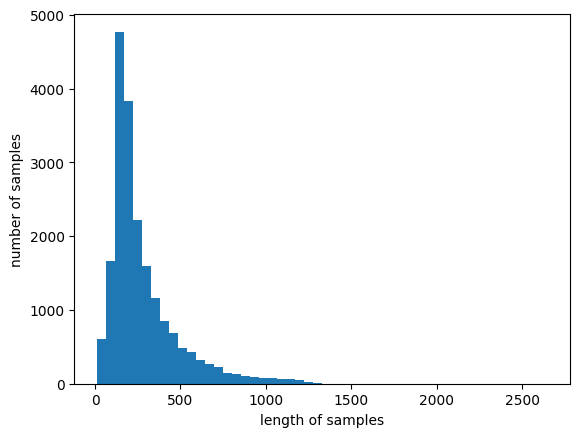

In [22]:
#서로 다른 길이의 데이터들을 동일한 길이로 일치시켜주는 패딩 작업
print('리뷰의 최대 길이 :',max(len(review) for review in encoded_X_train))
print('리뷰의 평균 길이 :',sum(map(len, encoded_X_train))/len(encoded_X_train))
plt.hist([len(review) for review in encoded_X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()


In [23]:
#전체를 최대값인 2651로 패딩하기는 애매함
def below_threshold_len(max_len, nested_list):
  count = 0
  for sentence in nested_list:
    if(len(sentence) <= max_len):
        count = count + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (count / len(nested_list))*100))

max_len = 500
below_threshold_len(max_len, encoded_X_train)

# 87%가 500이하


전체 샘플 중 길이가 500 이하인 샘플의 비율: 87.74499999999999


In [24]:
def pad_sequences(sentences, max_len):
  features = np.zeros((len(sentences), max_len), dtype=int)
  for index, sentence in enumerate(sentences):
    if len(sentence) != 0:
      features[index, :len(sentence)] = np.array(sentence)[:max_len]
  return features

padded_X_train = pad_sequences(encoded_X_train, max_len=max_len)
padded_X_valid = pad_sequences(encoded_X_valid, max_len=max_len)
padded_X_test = pad_sequences(encoded_X_test, max_len=max_len)

print('훈련 데이터의 크기 :', padded_X_train.shape)
print('검증 데이터의 크기 :', padded_X_valid.shape)
print('테스트 데이터의 크기 :', padded_X_test.shape)

#크기를 500으로 패딩함

훈련 데이터의 크기 : (20000, 500)
검증 데이터의 크기 : (5000, 500)
테스트 데이터의 크기 : (25000, 500)


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
#파이토치로 1d CNN 구현

In [26]:
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")
print("cpu와 cuda 중 다음 기기로 학습함:", device)


cpu와 cuda 중 다음 기기로 학습함: cpu


In [27]:
train_label_tensor = torch.tensor(np.array(y_train))
valid_label_tensor = torch.tensor(np.array(y_valid))
test_label_tensor = torch.tensor(np.array(y_test))
print(train_label_tensor[:5])

#y값 즉 0/1를 파이토치의 텐서로, 이후 상위 5개 출력

tensor([1, 1, 0, 0, 0])


In [28]:
# input.shape == (배치 크기, 임베딩 벡터의 차원, 문장 길이)
input = torch.randn(32, 16, 50)

# 선언 시 nn.Conv1d(임베딩 벡터의 차원, 커널의 개수, 커널 사이즈)
m = nn.Conv1d(16, 33, 3, stride=1)

# output.shape == (배치 크기, 커널의 개수, 컨볼루션 연산 결과 벡터)
output = m(input)
print(output.shape)


torch.Size([32, 33, 48])


In [29]:
class CNN(torch.nn.Module):
  def __init__(self, vocab_size, num_labels):
    super(CNN, self).__init__()

    # 오직 하나의 종류의 필터만 사용함.
    self.num_filter_sizes = 1 # 윈도우 5짜리 1개만 사용
    self.num_filters = 256

    self.word_embed = torch.nn.Embedding(num_embeddings=vocab_size, embedding_dim=128, padding_idx=0)
    # 윈도우 5짜리 1개만 사용
    self.conv1 = torch.nn.Conv1d(128, self.num_filters, 5, stride=1)
    self.dropout = torch.nn.Dropout(0.5)
    self.fc1 = torch.nn.Linear(1 * self.num_filters, num_labels, bias=True)

  def forward(self, inputs):
    # word_embed(inputs).shape == (배치 크기, 문장길이, 임베딩 벡터의 차원)
    # word_embed(inputs).permute(0, 2, 1).shape == (배치 크기, 임베딩 벡터의 차원, 문장 길이)
    embedded = self.word_embed(inputs).permute(0, 2, 1)

    # max를 이용한 maxpooling
    # conv1(embedded).shape == (배치 크기, 커널 개수, 컨볼루션 연산 결과) == ex) 32, 256, 496
    # conv1(embedded).permute(0, 2, 1).shape == (배치 크기, 컨볼루션 연산 결과, 커널 개수)
    # conv1(embedded).permute(0, 2, 1).max(1)[0]).shape == (배치 크기, 커널 개수)
    x = F.relu(self.conv1(embedded).permute(0, 2, 1).max(1)[0])

    # y_pred.shape == (배치 크기, 분류할 카테고리의 수)
    y_pred = self.fc1(self.dropout(x))

    return y_pred


In [30]:
encoded_train = torch.tensor(padded_X_train).to(torch.int64)
train_dataset = torch.utils.data.TensorDataset(encoded_train, train_label_tensor)
train_dataloader = torch.utils.data.DataLoader(train_dataset, shuffle=True, batch_size=32)

encoded_test = torch.tensor(padded_X_test).to(torch.int64)
test_dataset = torch.utils.data.TensorDataset(encoded_test, test_label_tensor)
test_dataloader = torch.utils.data.DataLoader(test_dataset, shuffle=True, batch_size=1)

encoded_valid = torch.tensor(padded_X_valid).to(torch.int64)
valid_dataset = torch.utils.data.TensorDataset(encoded_valid, valid_label_tensor)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, shuffle=True, batch_size=1)
# x data 텐서변환

In [31]:
model = CNN(vocab_size, num_labels = len(set(y_train)))
model.to(device)
#모델 객체 선언

CNN(
  (word_embed): Embedding(38723, 128, padding_idx=0)
  (conv1): Conv1d(128, 256, kernel_size=(5,), stride=(1,))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=2, bias=True)
)

In [33]:
criterion = nn.CrossEntropyLoss() #로스함수 크로스엔트로피
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # 학습률 0.001


In [35]:
def calculate_accuracy(logits, labels):
    # _, predicted = torch.max(logits, 1)
    predicted = torch.argmax(logits, dim=1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    accuracy = correct / total
    return accuracy
# 평가함수 - 모델의 정확도

In [36]:
def evaluate(model, valid_dataloader, criterion, device):
    val_loss = 0
    val_correct = 0
    val_total = 0

    model.eval() # 모델을 평가모드로 설정(필수)
    with torch.no_grad(): #기울기 계산 비활성화 -> 필수는 아니지만 효율성
        # 데이터로더로부터 배치 크기만큼의 데이터를 연속으로 로드
        for batch_X, batch_y in valid_dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # 모델의 예측값
            logits = model(batch_X)

            # 손실을 계산
            loss = criterion(logits, batch_y)

            # 정확도와 손실을 계산함
            val_loss += loss.item()
            val_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
            val_total += batch_y.size(0)

    val_accuracy = val_correct / val_total
    val_loss /= len(valid_dataloader)

    return val_loss, val_accuracy
# 평가함수 - 성능측정


In [38]:
num_epochs = 5

# Training loop
best_val_loss = float('inf')

# Training loop
for epoch in range(num_epochs):
    # Training
    train_loss = 0
    train_correct = 0
    train_total = 0
    model.train()
    for batch_X, batch_y in train_dataloader:
        # Forward pass
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        # batch_X.shape == (batch_size, max_len)
        logits = model(batch_X)

        # Compute loss
        loss = criterion(logits, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate training accuracy and loss
        train_loss += loss.item()
        train_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
        train_total += batch_y.size(0)

    train_accuracy = train_correct / train_total
    train_loss /= len(train_dataloader)

    # Validation
    val_loss, val_accuracy = evaluate(model, valid_dataloader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    # 검증 손실이 최소일 때 체크포인트 저장
    if val_loss < best_val_loss:
        print(f'Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. 체크포인트를 저장합니다.')
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_checkpoint.pth')


Epoch 1/5:
Train Loss: 0.1521, Train Accuracy: 0.9421
Validation Loss: 0.3377, Validation Accuracy: 0.8740
Validation loss improved from inf to 0.3377. 체크포인트를 저장합니다.
Epoch 2/5:
Train Loss: 0.0969, Train Accuracy: 0.9643
Validation Loss: 0.3890, Validation Accuracy: 0.8718
Epoch 3/5:
Train Loss: 0.0644, Train Accuracy: 0.9781
Validation Loss: 0.4367, Validation Accuracy: 0.8704
Epoch 4/5:
Train Loss: 0.0496, Train Accuracy: 0.9820
Validation Loss: 0.5064, Validation Accuracy: 0.8704
Epoch 5/5:
Train Loss: 0.0373, Train Accuracy: 0.9870
Validation Loss: 0.5725, Validation Accuracy: 0.8668


In [39]:
# 모델 로드/ 평가
# 모델 로드
model.load_state_dict(torch.load('best_model_checkpoint.pth'))

# 모델을 device에 올립니다.
model.to(device)


CNN(
  (word_embed): Embedding(38723, 128, padding_idx=0)
  (conv1): Conv1d(128, 256, kernel_size=(5,), stride=(1,))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=2, bias=True)
)

In [40]:
# 검증 데이터에 대한 정확도와 손실 계산
val_loss, val_accuracy = evaluate(model, valid_dataloader, criterion, device)

print(f'Best model validation loss: {val_loss:.4f}')
print(f'Best model validation accuracy: {val_accuracy:.4f}')


Best model validation loss: 0.3377
Best model validation accuracy: 0.8740


In [41]:
# 테스트 데이터에 대한 정확도와 손실 계산
test_loss, test_accuracy = evaluate(model, test_dataloader, criterion, device)

print(f'Best model test loss: {test_loss:.4f}')
print(f'Best model test accuracy: {test_accuracy:.4f}')


Best model test loss: 0.3597
Best model test accuracy: 0.8647


In [42]:
#모델 테스트
index_to_tag = {0 : '부정', 1 : '긍정'}

def predict(text, model, word_to_index, index_to_tag):
    # 모델 평가 모드
    model.eval()

    # 토큰화 및 정수 인코딩. OOV 문제 발생 시 <UNK> 토큰에 해당하는 인덱스 1 할당
    tokens = word_tokenize(text)
    token_indices = [word_to_index.get(token.lower(), 1) for token in tokens]

    # 리스트를 텐서로 변경
    input_tensor = torch.tensor([token_indices], dtype=torch.long).to(device)  # (1, seq_length)

    # 모델의 예측
    with torch.no_grad():
        logits = model(input_tensor)  # (1, output_dim)

    # 레이블 인덱스 예측
    _, predicted_index = torch.max(logits, dim=1)  # (1,)

    # 인덱스와 매칭되는 카테고리 문자열로 변경
    predicted_tag = index_to_tag[predicted_index.item()]

    return predicted_tag


In [43]:
test_input = "This movie was just way too overrated. The fighting was not professional and in slow motion. I was expecting more from a 200 million budget movie. The little sister of T.Challa was just trying too hard to be funny. The story was really dumb as well. Don't watch this movie if you are going because others say its great unless you are a Black Panther fan or Marvels fan."

predict(test_input, model, word_to_index, index_to_tag)


'부정'

In [44]:
test_input = " I was lucky enough to be included in the group to see the advanced screening in Melbourne on the 15th of April, 2012. And, firstly, I need to say a big thank-you to Disney and Marvel Studios. Now, the film... how can I even begin to explain how I feel about this film? It is, as the title of this review says a 'comic book triumph'. I went into the film with very, very high expectations and I was not disappointed. Seeing Joss Whedon's direction and envisioning of the film come to life on the big screen is perfect. The script is amazingly detailed and laced with sharp wit a humor. The special effects are literally mind-blowing and the action scenes are both hard-hitting and beautifully choreographed."

predict(test_input, model, word_to_index, index_to_tag)


'긍정'